# 5. Feature Selection

The initial dataset, following the Feature Engineering stage, contains 659 variables. To ensure model robustness, prevent overfitting, and meet the performance requirements of the Siemens Smart Infrastructure environment, a 5-phase feature selection engine was implemented.

The objective is to filter out noise and retain only the signals with the highest predictive power and temporal stability.

In [73]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
from src.code.class_pipeline_functions import FeatureSelection

sns.set_theme(style="whitegrid")

In [74]:
data_dir = '../data/features'

train_df = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fe.parquet'))
val_df = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fe.parquet'))

In [75]:
train_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,1,SSI027,SSI02710,SSI02710,0.0,-390277.0,0.7,263.09,18201.7,32730.0,...,1.2,0.3,1.900000,0.624500,1.183333,0.657590,2.3,8.666667,0.716667,2.154332
1,2,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,263.23,18201.7,32730.0,...,1.2,0.1,2.833333,1.266228,1.508333,1.036128,4.1,42.000000,1.325000,2.597814
2,3,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,280.30,18201.7,32730.0,...,1.4,0.6,3.933333,1.222020,1.916667,1.348961,4.4,8.333333,2.016667,2.285709
3,4,SSI027,SSI02710,SSI02710,0.0,1811758.0,1.3,281.28,18201.7,53544.1,...,1.4,1.0,4.866667,0.611010,2.316667,1.609536,4.4,5.400000,2.550000,1.915666
4,5,SSI027,SSI02710,SSI02710,0.0,80112.0,1.2,293.17,18201.7,53544.1,...,1.7,1.3,5.266667,0.230940,2.683333,1.774995,4.1,4.153846,2.583333,1.530521


In [76]:
val_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,44,SSI027,SSI02710,SSI02710,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723
1,45,SSI027,SSI02710,SSI02710,NaN,NaN,0.4,335.65,18743.8,88862.8,...,3.0,3.4,2.566667,0.152753,3.000000,0.378994,-0.7,0.794118,-0.433333,-0.791570
2,48,SSI027,SSI02710,SSI02710,NaN,NaN,0.5,313.13,18743.8,14255.6,...,2.4,3.5,2.900000,0.100000,2.916667,0.348590,-0.7,0.800000,-0.016667,-0.334681
3,43,SSI027,SSI02710,SSI0271002,NaN,NaN,0.2,308.86,18743.8,88862.8,...,3.4,3.2,2.600000,0.264575,3.083333,0.343335,-0.8,0.750000,-0.483333,-1.990283
4,44,SSI027,SSI02710,SSI0271002,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723


In [77]:
id_cols = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
target_cols = ['Orders cons. (anon)', 'Revenue cons. (anon)']

In [78]:
main_target = 'Revenue cons. (anon)'

X_train = train_df.drop(columns=id_cols + target_cols)
y_train = train_df[main_target].fillna(0) # filling the NaNs

### Phase 1: Temporal Leak Check (Integrity)
The first line of defense ensures the model does not utilize "future information" (**Data Leakage**). 
* **Logic:** If the forecast horizon is $h$, any feature derived from data within a window smaller than $h$ relative to the prediction point is removed.
* **Application:** For a next-month forecast ($h=1$), features using current month data (e.g., raw Revenue at time $t$) are eliminated, forcing the model to rely solely on consolidated historical data.

---

### Phase 2 & 3: Intra-Family & Correlation Pruning (Redundancy)
In this stage, we reduce dimensionality by eliminating features that provide redundant information to the model (**Multicollinearity**).
* **Spearman Correlation:** We use Spearman’s rank correlation ($\rho$) to identify the strongest "Lags" for each variable. Spearman is preferred over Pearson for its robustness against outliers and non-linear relationships:
$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
* **Pairwise Pruning:** If two variables show a correlation higher than **0.90**, only the representative with the highest correlation to the target (Revenue) is kept. This reduces the computational load and stabilizes model coefficients.



---

### Phase 4: Global Voting (Statistical Consensus)
We apply a "democratic" voting system between two models of different natures to find the "elite" predictors. A feature survives only if it receives at least **2 votes**.

1. **LassoCV (Linear Vote):** Uses $L_1$ regularization to penalize irrelevant variables, forcing their coefficients to zero. It is excellent for identifying direct linear relationships:
$$\min_{\beta} \left\{ \sum_{i=1}^n (y_i - \beta_0 - \sum_{j=1}^p x_{ij}\beta_j)^2 + \lambda \sum_{j=1}^p |\beta_j| \right\}$$
2. **Random Forest (Non-linear Vote):** Measures feature importance via the reduction in Gini impurity. It captures complex interactions (e.g., the impact of GDP only when inflation is within a specific range).

---

### Phase 5: Structural Rescue (Business Domain Knowledge)
The final phase is a safeguard mechanism based on Siemens S&OP business rules.
* **Rescue Logic:** Structural variables such as **Seasonality** (Sine/Cosine transformations of months) and **Organizational Hierarchy** (Parent Lags and Share of Parent) are reintroduced even if they failed the pure statistical tests.
* **Justification:** These variables ensure the model remains coherent with the physical and temporal structure of the company, allowing for consistent aggregated and disaggregated forecasting.

---

In [82]:
selector = FeatureSelection(
    # @elias: horizon=1 should be correct for recursive 1-step-ahead forecasting? 
    horizon=1,
    lag_top_k=2,       # top-2 lags per variable family (intra-family Pearson then prunes to 1 if correlated)
    corr_threshold=0.95, # lower → more aggressive redundancy removal in Phase 2+3
    min_votes=1,        # union of Lasso + RF (with min_votes=2  only 15 features survived)
    rf_top_n=50,        # RF selects top-50 by importance 
)

selector.fit(X_train, y_train)
selector.get_selection_report()

X_train_selected = selector.transform(X_train)

X_val_features = val_df.drop(columns=id_cols + target_cols)
X_val_selected = selector.transform(X_val_features)

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

Feature Selection Report

> Phase 1: Leakage: 0 variables removed

> Phase 2 & 3: Correlation: 267 variables removed
  Examples: China_Core_Inflation_Rate_Lag_12, China_Core_Inflation_Rate_Lag_3, China_GDP_Lag_12, China_GDP_Lag_6, China_GDP_Momentum_3_12, China_GDP_YoY_Diff, China_GDP_YoY_Ratio, China_GDP_from_Construction_Lag_1, China_GDP_from_Construction_Lag_6, China_GDP_from_Construction_Momentum_3_12...

> Phase 4: Voting: 330 variables removed
  Examples: China_Core_Inflation_Rate, China_Core_Inflation_Rate_Anomaly_12, China_Core_Inflation_Rate_Lag_1, China_Core_Inflation_Rate_Lag_6, China_Core_Inflation_Rate_Momentum_3_12, China_Core_Inflation_Rate_Rolling_Mean_12, China_Core_Inflation_Rate_Rolling_Mean_3, China_Core_Inflation_Rate_Rolling_Std_12, China_Core_Inflation_Rate_Rolling_Std_3, China_Core_Inflation_Rate_YoY_Diff...

> Structural Rescue: 41 variables rescued (added back)
  Examples: Month, Month_cos, Month_sin, Orders cons. (anon)_Months_Since_Last_Nonzero, Orders cons.

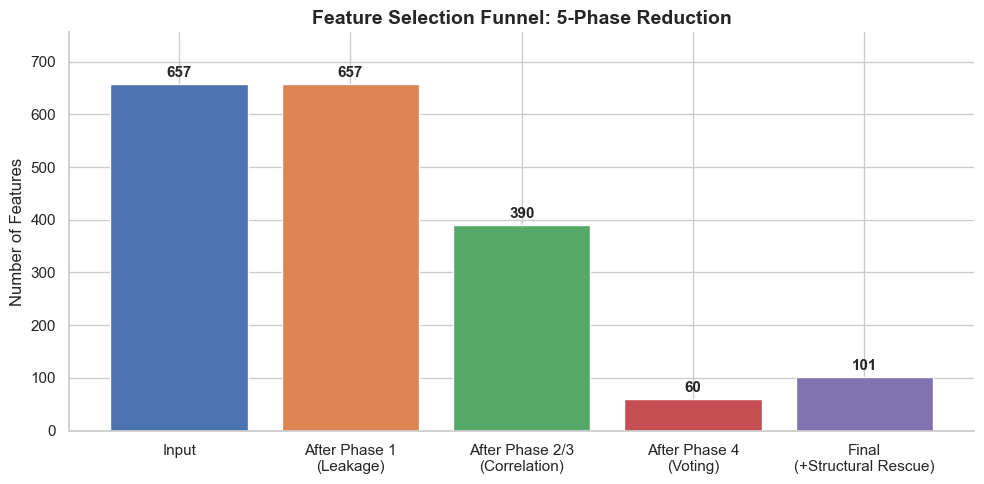

In [80]:
# Feature reduction funnel visualization
phases = ['Input', 'After Phase 1\n(Leakage)', 'After Phase 2/3\n(Correlation)', 'After Phase 4\n(Voting)', 'Final\n(+Structural Rescue)']
counts = [
    len(selector.input_features_),
    len(selector.input_features_) - len(selector.removal_log_.get('Phase 1: Leakage', [])),
    len(selector.input_features_) - len(selector.removal_log_.get('Phase 1: Leakage', [])) - len(selector.removal_log_.get('Phase 2 & 3: Correlation', [])),
    len(selector.input_features_) - len(selector.removal_log_.get('Phase 1: Leakage', [])) - len(selector.removal_log_.get('Phase 2 & 3: Correlation', [])) - len(selector.removal_log_.get('Phase 4: Voting', [])),
    len(selector.selected_features_),
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(phases, counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Selection Funnel: 5-Phase Reduction', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Save the feature-selected datasets
output_dir = '../data/features'

train_df_selected = pd.concat([train_df[id_cols + target_cols].reset_index(drop=True),
                                X_train_selected.reset_index(drop=True)], axis=1)
val_df_selected   = pd.concat([val_df[id_cols + target_cols].reset_index(drop=True),
                                X_val_selected.reset_index(drop=True)],   axis=1)

train_df_selected.to_parquet(os.path.join(output_dir, 'training_subsegment_fs.parquet'), index=False)
val_df_selected.to_parquet(os.path.join(output_dir,   'validation_subsegment_fs.parquet'), index=False)

print(f"Saved training:   {train_df_selected.shape}")
print(f"Saved validation: {val_df_selected.shape}")

Saved training:   (4237, 107)
Saved validation: (715, 107)
